In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
import pandas as pd

data = pd.read_csv("IMDB Dataset.csv")
data.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data.shape


(50000, 2)

In [ ]:
data['sentiment'].value_counts()


,count
sentiment,
positive,25000
negative,25000


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

data['review'] = data['review'].apply(clean_text)
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})


In [ ]:
data.head()


,review,sentiment
0,one reviewers mentioned watching oz episode ho...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically family little boy jake thinks zombie...,0
4,petter mattei love time money visually stunnin...,1


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(data['review'])

y = data['sentiment']


In [ ]:
X.shape


(50000, 3000)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
X_train.shape


(40000, 3000)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))


Logistic Regression Accuracy: 0.888
[[4351  610]
 [ 510 4529]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print(confusion_matrix(y_test, pred_dt))


Decision Tree Accuracy: 0.7194
[[3600 1361]
 [1445 3594]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))


Random Forest Accuracy: 0.8505
[[4267  694]
 [ 801 4238]]


In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train[:10000], y_train[:10000])

pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


SVM Accuracy: 0.8573
[[4227  734]
 [ 693 4346]]


In [ ]:
new_review = ["This movie was absolutely fantastic and amazing"]

cleaned = clean_text(new_review[0])
vector = tfidf.transform([cleaned])

prediction = lr.predict(vector)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")


Positive Review


In [ ]:
# Create a summary table
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_svm)
    ]
}

import pandas as pd
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df


,Model,Accuracy
0,Logistic Regression,0.8880
3,Linear SVM,0.8573
2,Random Forest,0.8505
1,Decision Tree,0.7194


In [ ]:
new_reviews = [
    "This movie was absolutely amazing and fantastic!",
    "Worst movie ever, I hated every minute of it.",
    "It was okay, not great but not terrible either."
]
cleaned = [clean_text(r) for r in new_reviews]
vectors = tfidf.transform(cleaned)
predictions = lr.predict(vectors)  # using Logistic Regression

for review, pred in zip(new_reviews, predictions):
    label = "Positive" if pred == 1 else "Negative"
    print(f"Review: {review}\nPrediction: {label}\n")


Review: This movie was absolutely amazing and fantastic!
Prediction: Positive

Review: Worst movie ever, I hated every minute of it.
Prediction: Negative

Review: It was okay, not great but not terrible either.
Prediction: Negative



In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from tensorflow.keras.datasets import imdb

# Load dataset (keep top 10,000 frequent words)
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Example review:", X_train[0])
print("Label:", y_train[0])  # 1 = positive, 0 = negative


Training samples: 25000
Testing samples: 25000
Example review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 3

In [ ]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)


In [ ]:
model_dense = Sequential([
    Embedding(vocab_size, 32, input_length=max_length),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_dense.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model_lstm = Sequential([
    Embedding(vocab_size, 32, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])


In [ ]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 341ms/step - accuracy: 0.6237 - loss: 0.6278 - val_accuracy: 0.8576 - val_loss: 0.3514
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 301ms/step - accuracy: 0.8807 - loss: 0.2996 - val_accuracy: 0.8502 - val_loss: 0.3586
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.9236 - loss: 0.2049 - val_accuracy: 0.8694 - val_loss: 0.3167
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 296ms/step - accuracy: 0.9505 - loss: 0.1458 - val_accuracy: 0.8440 - val_loss: 0.3723
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 302ms/step - accuracy: 0.9397 - loss: 0.1689 - val_accuracy: 0.8688 - val_loss: 0.3934


In [ ]:
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test)
print("LSTM Model Accuracy:", acc_lstm)


782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8606 - loss: 0.4191
LSTM Model Accuracy: 0.8578400015830994


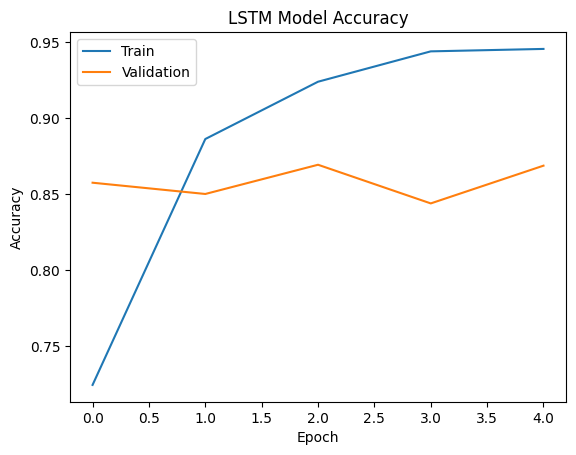

In [ ]:
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


In [ ]:
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []
    for word in words:
        if word in word_index and word_index[word] < 10000:
            encoded.append(word_index[word])
    return encoded

new_review = "This movie was absolutely fantastic and emotional"
encoded = encode_review(new_review)
padded = pad_sequences([encoded], maxlen=200)

prediction = model_lstm.predict(padded)

print("Prediction:", "Positive" if prediction[0] > 0.5 else "Negative")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
Prediction: Negative


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
